# ✈ Weather-Driven Destination Alternate Predictor ✈

### Core Idea

- According to the civil aviation rules, if weather conditions at a destination airport look bad, an FOO must designate an "alternate airport" in the flight plan. If a flight diverts unexpectedly, it costs the airline immense amounts of money
- This project will analyze real-time incoming weather feeds and predict the probability of a destination airport falling below landing minimums, allowing dispatchers to pick the safest alternate airport early.

### The Project Concept

In this project, we will use:
- A Decision Tree Classifier which is highly visual and easy to explain.
- It analyzes current weather patterns at a destination airport and predicts whether a flight is at high risk of a diversion.
- This predictive step helps a dispatcher to proactively select the most strategic alternate airport.

### Generate the Weather Dataset

First we will generate 500 historical flight arrivals at a target destination airport. The dataset includes visibility, cloud ceiling, and wind gusts directly to actual flight diversion events based on standard instrument landing system (ILS) minimums.

In [2]:
import pandas as pd
import numpy as np

# Set random seed for identical results
np.random.seed(42)
num_arrivals = 500

# Create simulated destination weather attributes
# Visibility in meters (e.g., standard safe visibility vs thick fog/heavy rain)
visibility_meters = np.random.uniform(300, 8000, size=num_arrivals)

# Cloud ceiling height in feet (how low the clouds are from the ground)
cloud_ceiling_feet = np.random.uniform(100, 3000, size=num_arrivals)

# Wind gust speed in knots (crosswinds make landing dangerous)
wind_gust_knots = np.random.uniform(5, 45, size=num_arrivals)

# Calculate the Flight Status (0 = Landed Safely, 1 = Diverted to Alternate)
# Diversions trigger if visibility is low, clouds are too low, or winds are too high
diversion_score = (
    (visibility_meters < 800).astype(int) * 4.0 +
    (cloud_ceiling_feet < 200).astype(int) * 3.5 +
    (wind_gust_knots > 30).astype(int) * 3.0
)

# Add minor random operational factors (e.g., runway maintenance, traffic congestion)
noise = np.random.normal(0, 1.0, size=num_arrivals)
total_score = diversion_score + noise

# Threshold to label the flight as a diversion (roughly 15-20% of flights)
is_diverted = (total_score > 3.0).astype(int)

# Build and Save the DataFrame
df_weather = pd.DataFrame({
    'arrival_id': [f"ARR_{i+1}" for i in range(num_arrivals)],
    'visibility_m': np.round(visibility_meters, 0),
    'cloud_ceiling_ft': np.round(cloud_ceiling_feet, 0),
    'wind_gust_kts': np.round(wind_gust_knots, 1),
    'was_diverted': is_diverted
})

df_weather.to_csv("destination_weather_diversions.csv", index=False)
print("✅ Weather dataset saved successfully as 'destination_weather_diversions.csv'")
print(df_weather['was_diverted'].value_counts(normalize=True))

✅ Weather dataset saved successfully as 'destination_weather_diversions.csv'
was_diverted
0    0.702
1    0.298
Name: proportion, dtype: float64


### Feature Distribution Analysis

After generating the dataset, let's visualize the distribution of each weather feature (`visibility_m`, `cloud_ceiling_ft`, `wind_gust_kts`) to understand their ranges and patterns.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the generated dataset
df = pd.read_csv('destination_weather_diversions.csv')

print('Dataset loaded successfully. Displaying the first 5 rows:')
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,arrival_id,visibility_m,cloud_ceiling_ft,wind_gust_kts,was_diverted
0,ARR_1,3184.0,2125.0,12.4,0
1,ARR_2,7621.0,1655.0,26.7,0
2,ARR_3,5936.0,998.0,39.9,0
3,ARR_4,4910.0,2460.0,34.3,0
4,ARR_5,1501.0,2086.0,37.3,1


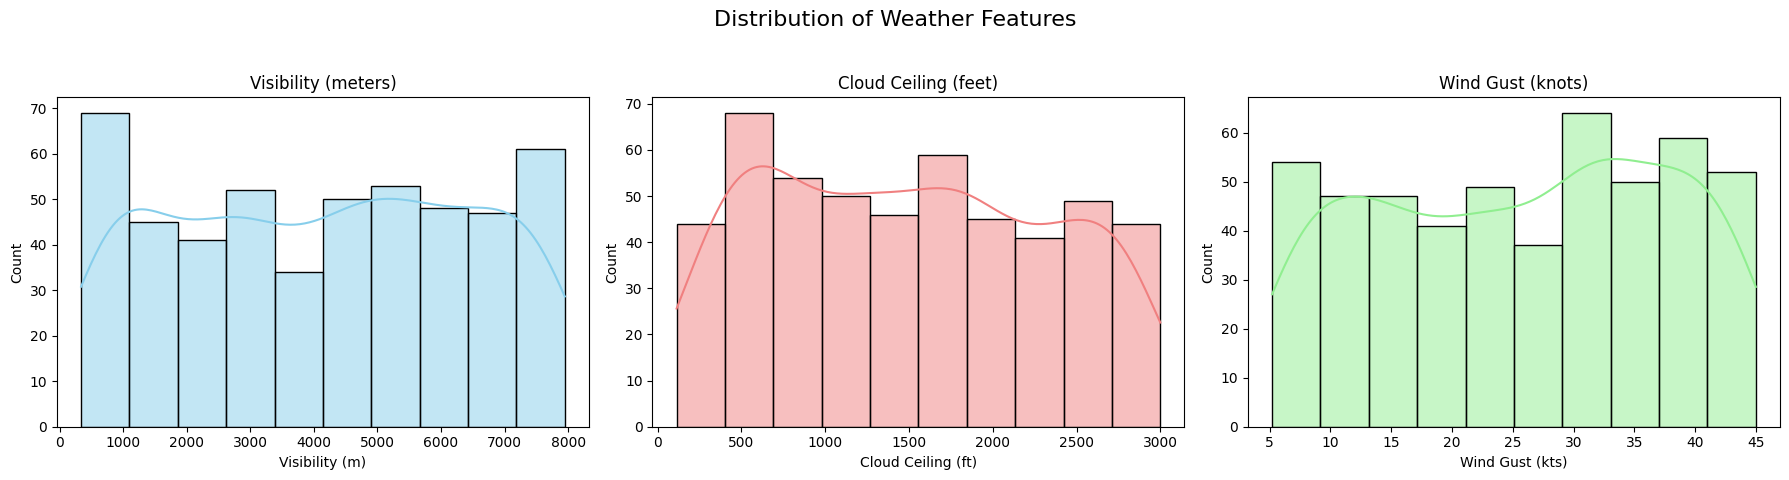

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Weather Features', fontsize=16)

sns.histplot(df['visibility_m'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Visibility (meters)')
axes[0].set_xlabel('Visibility (m)')
axes[0].set_ylabel('Count')

sns.histplot(df['cloud_ceiling_ft'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Cloud Ceiling (feet)')
axes[1].set_xlabel('Cloud Ceiling (ft)')
axes[1].set_ylabel('Count')

sns.histplot(df['wind_gust_kts'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Wind Gust (knots)')
axes[2].set_xlabel('Wind Gust (kts)')
axes[2].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Relationship between Features and Diversion Status

Now, let's explore how these weather features relate to the `was_diverted` status. From this, we will know which weather conditions are more likely to cause diversions.

/tmp/ipykernel_554/3843447976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='was_diverted', y='visibility_m', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_554/3843447976.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='was_diverted', y='cloud_ceiling_ft', data=df, ax=axes[1], palette='magma')
/tmp/ipykernel_554/3843447976.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='was_diverted', y='wind_gust_kts', data=df, ax=axes[2], palette='cividis')


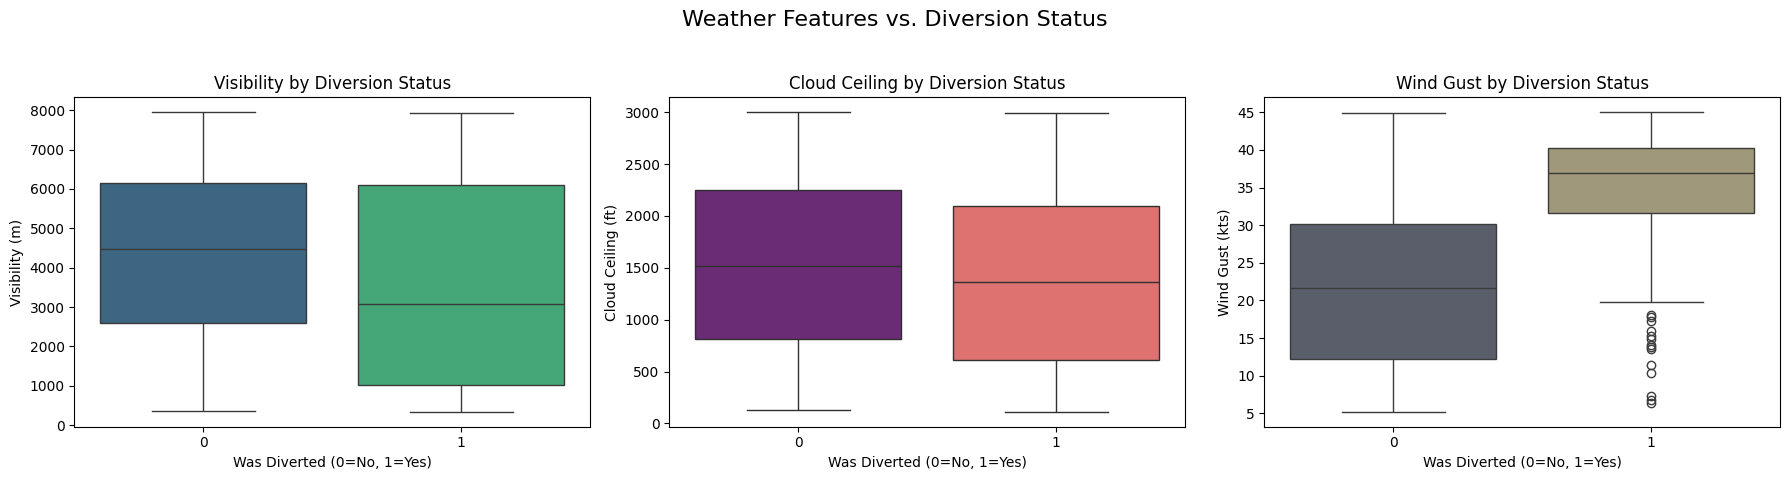

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Weather Features vs. Diversion Status', fontsize=16)

sns.boxplot(x='was_diverted', y='visibility_m', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Visibility by Diversion Status')
axes[0].set_xlabel('Was Diverted (0=No, 1=Yes)')
axes[0].set_ylabel('Visibility (m)')

sns.boxplot(x='was_diverted', y='cloud_ceiling_ft', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Cloud Ceiling by Diversion Status')
axes[1].set_xlabel('Was Diverted (0=No, 1=Yes)')
axes[1].set_ylabel('Cloud Ceiling (ft)')

sns.boxplot(x='was_diverted', y='wind_gust_kts', data=df, ax=axes[2], palette='cividis')
axes[2].set_title('Wind Gust by Diversion Status')
axes[2].set_xlabel('Was Diverted (0=No, 1=Yes)')
axes[2].set_ylabel('Wind Gust (kts)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Feature Correlation Analysis

Let's calculate the correlation matrix to understand the linear relationships between the features and the target variable `was_diverted`.

In [8]:
correlation_matrix = df[['visibility_m', 'cloud_ceiling_ft', 'wind_gust_kts', 'was_diverted']].corr()
display(correlation_matrix)

,visibility_m,cloud_ceiling_ft,wind_gust_kts,was_diverted
visibility_m,1.000000,0.010350,0.053927,-0.146005
cloud_ceiling_ft,0.010350,1.000000,-0.025980,-0.070209
wind_gust_kts,0.053927,-0.025980,1.000000,0.475850
was_diverted,-0.146005,-0.070209,0.475850,1.000000


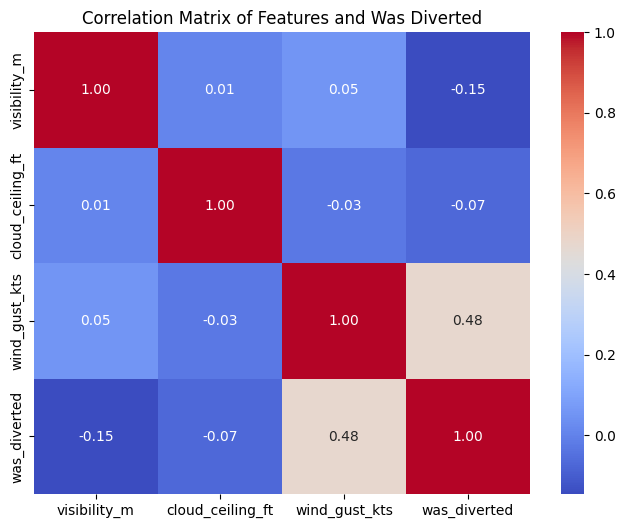

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Was Diverted')
plt.show()

### Data Splitting for Training and Testing

Before training our Decision Tree Classifier model, we need to prepare the data by separating the features (input variables) from the target (output variable). Then, we will split this data into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df[['visibility_m', 'cloud_ceiling_ft', 'wind_gust_kts']]
y = df['was_diverted']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (400, 3)
y_train shape: (400,)
X_test shape: (100, 3)
y_test shape: (100,)


### Build the Machine Learning Model

Next, we will train a Decision Tree Classifier model. The model maps out decisions exactly like a human dispatcher reads a weather report, for example: “If visibility is under X meters AND winds are above Y knots, then execute a diversion.”

Model Training Complete! Test Accuracy: 83.0%

--- 📊 CLASSIFICATION REPORT 📊 ---
              precision    recall  f1-score   support

           0       1.00      0.76      0.86        70
           1       0.64      1.00      0.78        30

    accuracy                           0.83       100
   macro avg       0.82      0.88      0.82       100
weighted avg       0.89      0.83      0.84       100

--- 📉 CONFUSION MATRIX 📉 ---


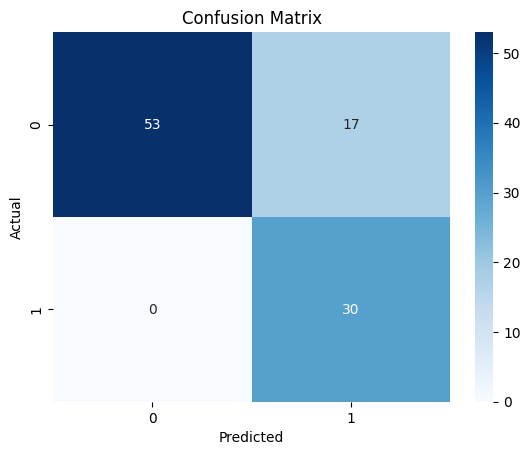


--- 🌳 AI DISPATCH DECISION LOGIC RULES 🌳 ---
|--- wind_gust_kts <= 29.90
|   |--- visibility_m <= 767.50
|   |   |--- cloud_ceiling_ft <= 357.00
|   |   |   |--- class: 0
|   |   |--- cloud_ceiling_ft >  357.00
|   |   |   |--- class: 1
|   |--- visibility_m >  767.50
|   |   |--- cloud_ceiling_ft <= 193.50
|   |   |   |--- class: 1
|   |   |--- cloud_ceiling_ft >  193.50
|   |   |   |--- class: 0
|--- wind_gust_kts >  29.90
|   |--- visibility_m <= 828.50
|   |   |--- class: 1
|   |--- visibility_m >  828.50
|   |   |--- visibility_m <= 950.00
|   |   |   |--- class: 0
|   |   |--- visibility_m >  950.00
|   |   |   |--- class: 1



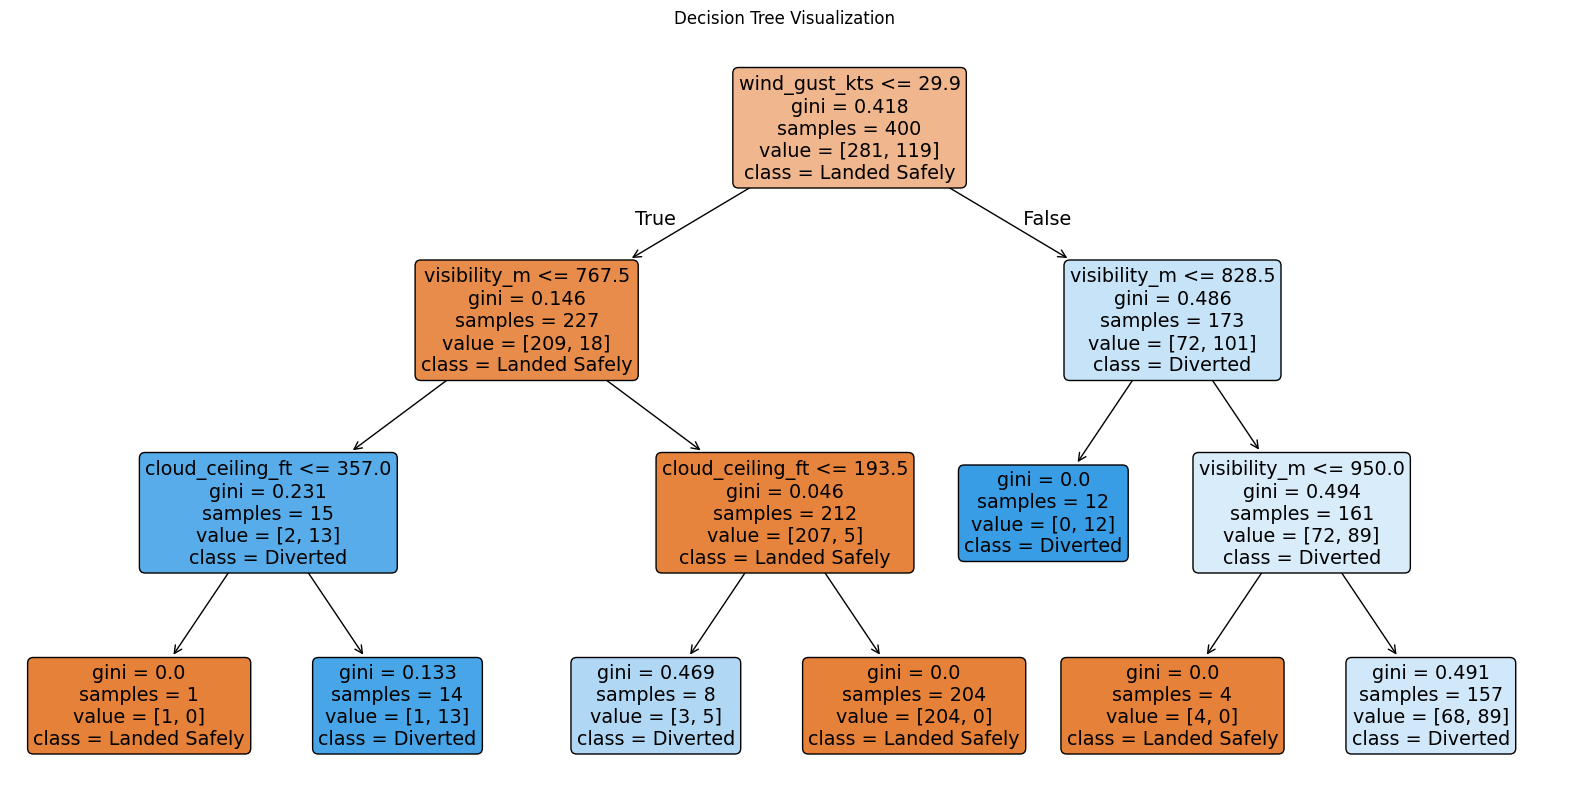


--- ✨ FEATURE IMPORTANCE ✨ ---
wind_gust_kts       0.591536
visibility_m        0.318235
cloud_ceiling_ft    0.090229
dtype: float64


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train a shallow decision tree (depth 3 keeps it simple and avoids overfitting)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Print accuracy and other classification metrics
y_pred = clf.predict(X_test)
print(f"Model Training Complete! Test Accuracy: {clf.score(X_test, y_test) * 100:.1f}%\n")
print("--- 📊 CLASSIFICATION REPORT 📊 ---")
print(classification_report(y_test, y_pred))

print("--- 📉 CONFUSION MATRIX 📉 ---")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Display the logic rules the AI discovered from the weather data
print("\n--- 🌳 AI DISPATCH DECISION LOGIC RULES 🌳 ---")
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=list(X.columns), class_names=['Landed Safely', 'Diverted'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

# Display Feature Importances
print("\n--- ✨ FEATURE IMPORTANCE ✨ ---")
feature_importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances)


### Create the Live Flight Dispatch Utility

For the final, let's write a simple function that simulates a live flight plan assessment. As a dispatcher, we can type in the current destination weather forecast (METAR), and the model will output a clear risk evaluation.

In [17]:
def check_flight_diversion_risk(visibility, ceiling, wind, high_risk_threshold=0.70, moderate_risk_threshold=0.30):
    """
    Assesses the flight diversion risk based on destination weather conditions.

    Args:
        visibility (float): Visibility in meters.
        ceiling (float): Cloud ceiling height in feet.
        wind (float): Wind gust speed in knots.
        high_risk_threshold (float): Probability threshold above which risk is considered high.
        moderate_risk_threshold (float): Probability threshold above which risk is considered moderate.

    Returns:
        None: Prints a risk briefing and recommendations.
    """
    # Input Validation
    if not all(isinstance(arg, (int, float)) for arg in [visibility, ceiling, wind]):
        print("ERROR: All weather parameters must be numeric.")
        return
    if not (0 <= visibility <= 10000 and 0 <= ceiling <= 10000 and 0 <= wind <= 100):
        print("WARNING: Weather parameters are outside typical ranges. Check input values.")

    # Format the input data
    live_input = pd.DataFrame([[visibility, ceiling, wind]],
                              columns=['visibility_m', 'cloud_ceiling_ft', 'wind_gust_kts'])

    # Predict probability of diversion
    # The model was trained on 'was_diverted' (0 or 1), so predict_proba returns
    # probabilities for [class_0, class_1]. We want the probability for class_1 (diverted).
    probability = clf.predict_proba(live_input)[0][1]

    print("\n--- 🔎 LIVE FLIGHT OPERATIONS RISK BRIEFING 🔎 ---")
    print(f"Destination Visibility : {visibility:<10} meters")
    print(f"Cloud Ceiling          : {ceiling:<10} feet")
    print(f"Wind Gust Speed        : {wind:<10} knots")
    print(f"Predicted Diversion Risk: {probability * 100:.1f}%")

    if probability >= high_risk_threshold:
        print("⚠️ ACTION REQUIRED: High diversion risk! Dispatcher must select a high-capacity alternate airport and load extra contingency fuel.")
    elif probability >= moderate_risk_threshold:
        print("🟡 CAUTION: Moderate diversion risk. Monitor conditions closely and prepare alternate options.")
    else:
        print("✅ FLIGHT RELEASE APPROVED: Weather parameters are within stable landing thresholds.")

# Test Scenario 1: A stormy day with low visibility and high winds (High Risk)
check_flight_diversion_risk(visibility=600, ceiling=150, wind=35)

# Test Scenario 2: A clear day (Low Risk)
check_flight_diversion_risk(visibility=5000, ceiling=2500, wind=12)

# Test Scenario 3: Borderline conditions (Moderate Risk)
# Assuming a scenario where wind is not high enough for high risk, but visibility/ceiling are not ideal
check_flight_diversion_risk(visibility=900, ceiling=300, wind=25, high_risk_threshold=0.8, moderate_risk_threshold=0.3)


--- 🔎 LIVE FLIGHT OPERATIONS RISK BRIEFING 🔎 ---
Destination Visibility : 600        meters
Cloud Ceiling          : 150        feet
Wind Gust Speed        : 35         knots
Predicted Diversion Risk: 100.0%
⚠️ ACTION REQUIRED: High diversion risk! Dispatcher must select a high-capacity alternate airport and load extra contingency fuel.

--- 🔎 LIVE FLIGHT OPERATIONS RISK BRIEFING 🔎 ---
Destination Visibility : 5000       meters
Cloud Ceiling          : 2500       feet
Wind Gust Speed        : 12         knots
Predicted Diversion Risk: 0.0%
✅ FLIGHT RELEASE APPROVED: Weather parameters are within stable landing thresholds.

--- 🔎 LIVE FLIGHT OPERATIONS RISK BRIEFING 🔎 ---
Destination Visibility : 900        meters
Cloud Ceiling          : 300        feet
Wind Gust Speed        : 25         knots
Predicted Diversion Risk: 0.0%
✅ FLIGHT RELEASE APPROVED: Weather parameters are within stable landing thresholds.
